# 🫀 Heartz — Data Science Pipeline
## Persiapan Dataset Audio untuk CNN 2D Klasifikasi 20 Suku Kata

**Tim:** CC26-PSU064 | **Role:** Data Scientist

### Pipeline:
1. **Setup** — Install dependencies & inisialisasi folder
2. **Preparation** — Konversi file media manual ke format standar
3. **Splitting** — Potong audio menjadi clip per suku kata
4. **Cleaning** — Denoise, filter, normalisasi
5. **Augmentasi** — Gandakan data dengan variasi
6. **EDA** — Analisis & visualisasi dataset
7. **Export** — Serah terima ke tim AI Engineering

### 20 Kelas Target:
| Kelompok | Kelas |
|----------|-------|
| Vokal | A, I, U, E, O |
| Ba-set | Ba, Bi, Bu, Be, Bo |
| Pa-set | Pa, Pi, Pu, Pe, Po |
| Ma-set | Ma, Mi, Mu, Me, Mo |

---
## ⚙️ STEP 0: Setup Environment

In [1]:
# Install semua dependencies (jalankan sekali saja)
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Inisialisasi folder dan import semua module
from config import *
from utils import *
from prepare_manual import *
from splitter import *
from cleaner import *
from augmentor import *
from eda import *

# Buat semua folder yang dibutuhkan
ensure_dirs()

print(f"\n📁 Project Dir : {BASE_DIR}")
print(f"🏷️  Kelas Target: {ALL_CLASSES}")
print(f"🎵 Sample Rate : {SAMPLE_RATE} Hz")
print(f"⏱️  Durasi Clip : {CLIP_DURATION_MIN}-{CLIP_DURATION_MAX}s")

✅ Semua direktori siap (20 kelas)

📁 Project Dir : D:\STUPEN\Heartz\data-science
🏷️  Kelas Target: ['A', 'I', 'U', 'E', 'O', 'Ba', 'Bi', 'Bu', 'Be', 'Bo', 'Pa', 'Pi', 'Pu', 'Pe', 'Po', 'Ma', 'Mi', 'Mu', 'Me', 'Mo']
🎵 Sample Rate : 16000 Hz
⏱️  Durasi Clip : 0.4-2.0s


---
## 📥 STEP 1: Preparation — Siapkan Data Manual

Karena tidak menggunakan scraper otomatis, letakkan file media (video/audio) yang telah diunduh secara manual ke dalam folder dataset/manual_downloads/.

Jalankan cell di bawah ini untuk mengonversi semua file tersebut menjadi format standar (WAV, 16kHz, Mono) yang dibutuhkan oleh pipeline.

In [3]:
# Lihat daftar file yang sudah Anda siapkan secara manual
list_manual_files()

📋 Isi folder manual_downloads:
  [1] A.mp3
  [2] Be.mp3
  [3] Be2.mp3
  [4] Be3.mp3
  [5] Bo.mp3
  [6] Bo2.mp3
  [7] Bo3.mp3
  [8] E.mp3
  [9] I.mp3
  [10] Me.mp3
  [11] Me2.mp3
  [12] Me3.mp3
  [13] Mo.mp3
  [14] O.mp3
  [15] O2.mp3
  [16] O3.mp3
  [17] Pe.mp3
  [18] Po.mp3
  [19] U.mp3


[WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/A.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/Be.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/Be2.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/Be3.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/Bo.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/Bo2.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/Bo3.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/E.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/I.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/Me.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/Me2.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/manual_downloads/Me3.mp3'),
 WindowsPath('D:/STUPEN/Heartz/data-science/datas

In [4]:
# Konversi semua file di manual_downloads/ ke format .wav di downloads/
convert_manual_to_wav()

✅ Semua direktori siap (20 kelas)
📂 Ditemukan 19 file di manual_downloads. Memulai konversi...


Converting: 100%|██████████| 19/19 [00:00<00:00, 6331.28it/s]


✅ Konversi selesai: 19/19 berhasil diproses.
📁 Hasil konversi disimpan di: D:\STUPEN\Heartz\data-science\dataset\downloads


In [5]:
# Lihat file yang sudah berhasil dikonversi dan siap dipotong
list_downloads()

[WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/A.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/Ba.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/Be.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/Be2.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/Be3.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/Bi.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/Bo.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/Bo2.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/Bo3.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/Bu.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/E.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/I.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/Ma.wav'),
 WindowsPath('D:/STUPEN/Heartz/data-science/dataset/downloads/M

---
## ✂️ STEP 2: Splitting — Potong Audio per Suku Kata

**Dua Approach:**
1. **split_audio_with_labels()** - Jika jumlah region PERSIS sama dengan jumlah label (file clean)
2. **split_audio_selective()** - Jika file panjang, ambil hanya region yang relevan (file YouTube)

In [6]:
# Lihat file yang tersedia
download_files = list_downloads()
if download_files:
    print("📋 Download files:")
    for i, f in enumerate(download_files):
        print(f"   [{i}] {f.name}")

📋 Download files:
   [0] A.wav
   [1] Ba.wav
   [2] Be.wav
   [3] Be2.wav
   [4] Be3.wav
   [5] Bi.wav
   [6] Bo.wav
   [7] Bo2.wav
   [8] Bo3.wav
   [9] Bu.wav
   [10] E.wav
   [11] I.wav
   [12] Ma.wav
   [13] Me.wav
   [14] Me2.wav
   [15] Me3.wav
   [16] Mi.wav
   [17] Mo.wav
   [18] Mu.wav
   [19] O.wav
   [20] O2.wav
   [21] O3.wav
   [22] Pa.wav
   [23] Pe.wav
   [24] Pi.wav
   [25] Po.wav
   [26] Pu.wav
   [27] U.wav


In [7]:
# ============================================
# APPROACH 1: split_audio_with_labels()
# Gunakan jika jumlah region PERSIS sama dengan jumlah label
# ============================================
# Uncomment dan edit jika file Anda sudah bersih (tidak perlu selective)

# split_audio_with_labels(
#     "dataset/downloads/aiueo_babibubebo.wav",
#     "dataset/raw",
#     labels=["A", "I", "U", "E", "O", "Ba", "Bi", "Bu", "Be", "Bo"],
#     top_db=30
# )

In [8]:
# 🔍 PREVIEW: Lihat semua region yang terdeteksi di setiap file
# Catat region index mana saja yang merupakan suku kata yang diinginkan

print("="*80)
print("📋 PREVIEW SEMUA REGION — Tentukan Mana yang Akan Diambil")
print("="*80)

# Edit config di sini sesuai file Anda
files_config = [
    ("dataset/downloads/A.wav", "A"),
    ("dataset/downloads/I.wav", "I"),
    ("dataset/downloads/U.wav", "U"),
    ("dataset/downloads/E.wav", "E"),
    ("dataset/downloads/O.wav", "O"),
    ("dataset/downloads/O2.wav", "O2"),
    ("dataset/downloads/O3.wav", "O3"),
    ("dataset/downloads/Ba.wav", "Ba"),
    ("dataset/downloads/Bi.wav", "Bi"),
    ("dataset/downloads/Bu.wav", "Bu"),
    ("dataset/downloads/Be.wav", "Be"),
    ("dataset/downloads/Be2.wav", "Be2"),
    ("dataset/downloads/Be3.wav", "Be3"),
    ("dataset/downloads/Bo.wav", "Bo"),
    ("dataset/downloads/Bo2.wav", "Bo2"),
    ("dataset/downloads/Bo3.wav", "Bo3"),
    ("dataset/downloads/Pa.wav", "Pa"),
    ("dataset/downloads/Pi.wav", "Pi"),
    ("dataset/downloads/Pu.wav", "Pu"),
    ("dataset/downloads/Pe.wav", "Pe"),
    ("dataset/downloads/Po.wav", "Po"),
    ("dataset/downloads/Ma.wav", "Ma"),
    ("dataset/downloads/Mi.wav", "Mi"),
    ("dataset/downloads/Mu.wav", "Mu"),
    ("dataset/downloads/Me.wav", "Me"),
    ("dataset/downloads/Me2.wav", "Me2"),
    ("dataset/downloads/Me3.wav", "Me3"),
    ("dataset/downloads/Mo.wav", "Mo"),
]

# Store hasil preview untuk automatic labeling
preview_data = {}

for file_path, expected_content in files_config:
    from pathlib import Path
    file_name = Path(file_path).name
    
    try:
        # Deteksi region
        y, sr = librosa.load(file_path, sr=16000)
        regions = librosa.effects.split(y, top_db=30)
        
        preview_data[file_name] = {
            'label': expected_content,
            'num_regions': len(regions),
            'regions': regions
        }
        
        print(f"\n📁 {file_name} (Expected: {expected_content})")
        print(f"   Total region terdeteksi: {len(regions)}\n")
        print(f"   {'Idx':<5} {'Start':<10} {'End':<10} {'Durasi':<8}")
        print(f"   {'-'*40}")
        
        for i, (start, end) in enumerate(regions):
            start_sec = start / sr
            end_sec = end / sr
            duration = (end - start) / sr
            print(f"   {i:<5} {start_sec:<10.2f} {end_sec:<10.2f} {duration:<8.2f}s")
        
        print()
    except FileNotFoundError:
        print(f"\n⚠️  File tidak ditemukan: {file_path}")
        print()

📋 PREVIEW SEMUA REGION — Tentukan Mana yang Akan Diambil

📁 A.wav (Expected: A)
   Total region terdeteksi: 141

   Idx   Start      End        Durasi  
   ----------------------------------------
   0     0.93       1.38       0.45    s
   1     1.70       2.18       0.48    s
   2     2.40       2.85       0.45    s
   3     3.07       3.49       0.42    s
   4     3.81       4.19       0.38    s
   5     4.54       4.93       0.38    s
   6     5.28       5.73       0.45    s
   7     6.08       6.53       0.45    s
   8     6.82       7.23       0.42    s
   9     7.52       7.97       0.45    s
   10    8.32       8.74       0.42    s
   11    9.09       9.47       0.38    s
   12    9.86       10.24      0.38    s
   13    10.59      11.01      0.42    s
   14    11.26      11.71      0.45    s
   15    12.03      12.51      0.48    s
   16    12.80      13.28      0.48    s
   17    13.57      14.02      0.45    s
   18    14.34      14.78      0.45    s
   19    15.39      15.8

In [9]:
# 🤖 AUTO-GENERATE MAPPING untuk semua file (dengan validasi detail)
# Setiap file individual sudah diasumsikan pure (hanya 1 label)

print("="*80)
print("🤖 AUTO-LABELING SEMUA REGION (Dengan Validasi Detail)")
print("="*80)

# Re-scan semua file untuk pastikan jumlah region AKURAT
from pathlib import Path
import librosa

all_files_mapping = {}
split_calls = []
validation_errors = []

for file_name, preview_info in preview_data.items():
    label = preview_info['label']
    file_path = f"dataset/downloads/{file_name}"
    
    try:
        # Re-load file untuk double-check jumlah region
        y, sr = librosa.load(file_path, sr=16000)
        regions = librosa.effects.split(y, top_db=30)
        num_regions = len(regions)
        
        if num_regions == 0:
            print(f"\n⚠️  SKIP {file_name}: Tidak ada region terdeteksi")
            validation_errors.append((file_name, "Tidak ada region"))
            continue
        
        # Buat mapping VALID
        file_mapping = {i: label for i in range(num_regions)}
        all_files_mapping[file_name] = file_mapping
        
        print(f"\n✅ {file_name}")
        print(f"   Label    : {label}")
        print(f"   Region   : {num_regions}")
        print(f"   Indices  : 0-{num_regions-1} ({num_regions} valid indices)")
        
        split_calls.append((file_path, "dataset/raw", file_mapping))
        
    except FileNotFoundError:
        print(f"\n❌ {file_name}: File tidak ditemukan di downloads/")
        validation_errors.append((file_name, "File not found"))
    except Exception as e:
        print(f"\n❌ {file_name}: Error saat deteksi region - {str(e)[:80]}")
        validation_errors.append((file_name, str(e)[:50]))

print("\n" + "="*70)
print(f"📋 Validation Summary:")
print(f"   ✅ Valid files : {len(split_calls)}")
print(f"   ⚠️  Error files : {len(validation_errors)}")
print("="*70)

if validation_errors:
    print("\n⚠️  Error details:")
    for fname, error in validation_errors:
        print(f"   - {fname}: {error}")

if split_calls:
    print(f"\n🔪 SPLITTING {len(split_calls)} file...")
    success_count = 0
    error_count = 0
    
    for file_path, output_dir, mapping in split_calls:
        try:
            split_audio_selective(file_path, output_dir, mapping, top_db=30)
            print(f"✅ {Path(file_path).name}")
            success_count += 1
        except Exception as e:
            print(f"❌ {Path(file_path).name}: {str(e)[:100]}")
            error_count += 1
    
    print(f"\n📊 Split Result: {success_count} berhasil, {error_count} gagal")
    if error_count == 0:
        print("✅ Semua split SEMPURNA!")
else:
    print("\n⚠️  Tidak ada file valid untuk di-split!")

🤖 AUTO-LABELING SEMUA REGION (Dengan Validasi Detail)

✅ A.wav
   Label    : A
   Region   : 141
   Indices  : 0-140 (141 valid indices)

✅ I.wav
   Label    : I
   Region   : 141
   Indices  : 0-140 (141 valid indices)

✅ U.wav
   Label    : U
   Region   : 148
   Indices  : 0-147 (148 valid indices)

✅ E.wav
   Label    : E
   Region   : 173
   Indices  : 0-172 (173 valid indices)

✅ O.wav
   Label    : O
   Region   : 48
   Indices  : 0-47 (48 valid indices)

✅ O2.wav
   Label    : O2
   Region   : 51
   Indices  : 0-50 (51 valid indices)

✅ O3.wav
   Label    : O3
   Region   : 48
   Indices  : 0-47 (48 valid indices)

✅ Ba.wav
   Label    : Ba
   Region   : 118
   Indices  : 0-117 (118 valid indices)

✅ Bi.wav
   Label    : Bi
   Region   : 128
   Indices  : 0-127 (128 valid indices)

✅ Bu.wav
   Label    : Bu
   Region   : 110
   Indices  : 0-109 (110 valid indices)

✅ Be.wav
   Label    : Be
   Region   : 50
   Indices  : 0-49 (50 valid indices)

✅ Be2.wav
   Label    : Be2
   R

In [10]:
# 🧹 Cleanup: Hapus HANYA folder yang tidak ada di downloads/
# Keep semua folder yang sesuai dengan file di downloads (termasuk Me2, Me3, Be2, Be3, dll)

import shutil
from pathlib import Path

print("="*70)
print("🔍 Smart Cleanup — Hapus Folder Invalid Saja")
print("="*70)

# Scan file apa yang ada di downloads
downloads_path = Path("dataset/downloads")
available_files = set()

if downloads_path.exists():
    for wav_file in downloads_path.glob("*.wav"):
        # Ambil nama tanpa extension (A.wav -> A, Me2.wav -> Me2)
        file_base = wav_file.stem
        available_files.add(file_base)
    
    print(f"\n📁 File yang ada di downloads/ ({len(available_files)} file):")
    for fname in sorted(available_files):
        print(f"   ✓ {fname}")
else:
    print(f"⚠️  Folder downloads/ tidak ditemukan")

# Scan folder di dataset/raw
raw_path = Path("dataset/raw")
folders_to_cleanup = []

print(f"\n\n📁 Folder di dataset/raw/:")
for cls_dir in sorted(raw_path.glob("*/")):
    if cls_dir.is_dir():
        folder_name = cls_dir.name
        file_count = len(list(cls_dir.glob("*.wav")))
        
        if folder_name in available_files:
            print(f"   ✅ {folder_name:<10} — {file_count} file (OK, ada di downloads)")
        else:
            print(f"   ❌ {folder_name:<10} — {file_count} file (INVALID, tidak ada di downloads!)")
            folders_to_cleanup.append((folder_name, cls_dir, file_count))

# Cleanup hanya folder yang INVALID
if folders_to_cleanup:
    print(f"\n\n🗑️  Menghapus {len(folders_to_cleanup)} folder invalid:")
    for folder_name, folder_path, file_count in folders_to_cleanup:
        try:
            shutil.rmtree(folder_path)
            print(f"   ✅ Hapus: {folder_name} ({file_count} file)")
        except Exception as e:
            print(f"   ❌ Gagal hapus {folder_name}: {str(e)}")
else:
    print(f"\n\n✅ Tidak ada folder invalid. Semua folder sudah sesuai dengan downloads!")

print("\n" + "="*70)

🔍 Smart Cleanup — Hapus Folder Invalid Saja

📁 File yang ada di downloads/ (28 file):
   ✓ A
   ✓ Ba
   ✓ Be
   ✓ Be2
   ✓ Be3
   ✓ Bi
   ✓ Bo
   ✓ Bo2
   ✓ Bo3
   ✓ Bu
   ✓ E
   ✓ I
   ✓ Ma
   ✓ Me
   ✓ Me2
   ✓ Me3
   ✓ Mi
   ✓ Mo
   ✓ Mu
   ✓ O
   ✓ O2
   ✓ O3
   ✓ Pa
   ✓ Pe
   ✓ Pi
   ✓ Po
   ✓ Pu
   ✓ U


📁 Folder di dataset/raw/:
   ✅ A          — 460 file (OK, ada di downloads)
   ✅ Ba         — 208 file (OK, ada di downloads)
   ✅ Be         — 196 file (OK, ada di downloads)
   ✅ Be2        — 204 file (OK, ada di downloads)
   ✅ Be3        — 196 file (OK, ada di downloads)
   ✅ Bi         — 64 file (OK, ada di downloads)
   ✅ Bo         — 208 file (OK, ada di downloads)
   ✅ Bo2        — 216 file (OK, ada di downloads)
   ✅ Bo3        — 216 file (OK, ada di downloads)
   ✅ Bu         — 216 file (OK, ada di downloads)
   ✅ E          — 320 file (OK, ada di downloads)
   ✅ I          — 500 file (OK, ada di downloads)
   ✅ Ma         — 784 file (OK, ada di downloads)
   ✅ Me     

In [11]:
# Cek status dataset/raw setelah splitting — Validasi vs downloads/
print("="*70)
print("📊 HASIL SPLITTING — Dataset RAW")
print("="*70)

# Scan file apa yang ada di downloads (referensi)
downloads_path = Path("dataset/downloads")
available_files = set()

if downloads_path.exists():
    for wav_file in downloads_path.glob("*.wav"):
        file_base = wav_file.stem
        available_files.add(file_base)

# Scan folder di dataset/raw
raw_path = Path("dataset/raw")
found_classes = {}
invalid_folders = []

print(f"\n📋 Validasi terhadap downloads/ ({len(available_files)} file tersedia):\n")

for cls_dir in sorted(raw_path.glob("*/")):
    if cls_dir.is_dir():
        class_name = cls_dir.name
        file_count = len(list(cls_dir.glob("*.wav")))
        
        if class_name in available_files:
            found_classes[class_name] = file_count
            print(f"  ✅ {class_name:<10} — {file_count:3d} file")
        else:
            invalid_folders.append((class_name, file_count))
            print(f"  ❌ {class_name:<10} — {file_count:3d} file (TIDAK ADA DI DOWNLOADS!)")

# Ringkas
print("\n" + "-"*70)
print(f"✅ Folder valid (ada di downloads): {len(found_classes)}")
print(f"❌ Folder invalid (tidak ada di downloads): {len(invalid_folders)}")

if invalid_folders:
    print("\n⚠️  Folder yang harus dihapus:")
    for folder_name, count in invalid_folders:
        print(f"   - {folder_name} ({count} file)")

# Cek completeness
if available_files and found_classes:
    coverage = len(found_classes) / len(available_files) * 100
    print(f"\n📈 Kelengkapan split: {len(found_classes)}/{len(available_files)} ({coverage:.0f}%)")

total_files = sum(found_classes.values())
print(f"📦 Total file di raw: {total_files}")
print("="*70)

📊 HASIL SPLITTING — Dataset RAW

📋 Validasi terhadap downloads/ (28 file tersedia):

  ✅ A          — 460 file
  ✅ Ba         — 208 file
  ✅ Be         — 196 file
  ✅ Be2        — 204 file
  ✅ Be3        — 196 file
  ✅ Bi         —  64 file
  ✅ Bo         — 208 file
  ✅ Bo2        — 216 file
  ✅ Bo3        — 216 file
  ✅ Bu         — 216 file
  ✅ E          — 320 file
  ✅ I          — 500 file
  ✅ Ma         — 784 file
  ✅ Me         — 220 file
  ✅ Me2        — 232 file
  ✅ Me3        — 228 file
  ✅ Mi         — 804 file
  ✅ Mo         — 624 file
  ✅ Mu         — 296 file
  ✅ O          — 180 file
  ✅ O2         — 200 file
  ✅ O3         — 192 file
  ✅ Pa         — 656 file
  ✅ Pe         — 480 file
  ✅ Pi         — 452 file
  ✅ Po         — 528 file
  ✅ Pu         — 492 file
  ✅ U          — 440 file

----------------------------------------------------------------------
✅ Folder valid (ada di downloads): 28
❌ Folder invalid (tidak ada di downloads): 0

📈 Kelengkapan split: 28/28 (100

---
## 🧹 STEP 3: Cleaning — Bersihkan Audio

Pipeline cleaning otomatis untuk SEMUA kelas (termasuk variant seperti Be2, Be3, Bo2, Bo3, O2, O3, Me2, Me3):
1. Trim silence di awal/akhir
2. Noise reduction (spectral gating)
3. Bandpass filter (80Hz - 7500Hz)
4. Volume normalization dengan RMS (-20 dBFS)
5. Standarisasi durasi (pad/trim ke 1.5 detik)
6. Validasi kualitas

**Auto-detect mode:** Fungsi `clean_all()` akan otomatis mendeteksi SEMUA folder di `dataset/raw/` dan memproses semuanya, bukan hanya 20 kelas target saja. Jadi Be2, Be3, dll. akan tetap diproses dengan benar.

In [12]:
# Bersihkan SEMUA kelas sekaligus
# Input : dataset/raw/{kelas}/*.wav
# Output: dataset/clean/{kelas}/*.wav

clean_results = clean_all()

📋 Auto-detect mode: Menemukan 28 folder
   Kelas: A, Ba, Be, Be2, Be3, Bi, Bo, Bo2, Bo3, Bu, E, I, Ma, Me, Me2, Me3, Mi, Mo, Mu, O, O2, O3, Pa, Pe, Pi, Po, Pu, U

🧹 Audio Cleaning Pipeline
   Kelas    : 28
   Raw Dir  : D:\STUPEN\Heartz\data-science\dataset\raw
   Clean Dir: D:\STUPEN\Heartz\data-science\dataset\clean



Cleaning:   4%|▎         | 1/28 [00:02<01:07,  2.52s/it]

  ✅ A: 115 berhasil, 0 gagal, 345 di-skip


Cleaning:   7%|▋         | 2/28 [00:03<00:43,  1.66s/it]

  ✅ Ba: 52 berhasil, 0 gagal, 156 di-skip


...

  ✅ Po: 132 berhasil, 0 gagal, 396 di-skip


Cleaning:  96%|█████████▋| 27/28 [00:49<00:02,  2.61s/it]

  ✅ Pu: 123 berhasil, 0 gagal, 369 di-skip


Cleaning: 100%|██████████| 28/28 [00:51<00:00,  1.84s/it]

  ✅ U: 110 berhasil, 0 gagal, 330 di-skip

📊 Ringkasan Cleaning
   ✅ Total berhasil : 2453
   ❌ Total gagal    : 0


In [13]:
# Atau bersihkan kelas tertentu saja:
# clean_results = clean_all(classes=["Ba", "Ma", "A"])

In [14]:
# Cek status dataset/clean setelah cleaning
print_dataset_summary(CLEAN_DIR, "Dataset CLEAN (Hasil Cleaning)")


📊 Dataset CLEAN (Hasil Cleaning)
Kelas        Jumlah
------------------
A               460  ✅
Ba              208  ✅
Be              196  ✅
Be2             204  ✅
Be3             196  ✅
Bi               64  ❌
Bo              208  ✅
Bo2             216  ✅
Bo3             216  ✅
Bu              216  ✅
E               320  ✅
I               500  ✅
Ma              784  ✅
Me              220  ✅
Me2             232  ✅
Me3             228  ✅
Mi              804  ✅
Mo              624  ✅
Mu              296  ✅
O               180  ✅
O2              200  ✅
O3              192  ✅
Pa              656  ✅
Pe              480  ✅
Pi              452  ✅
Po              528  ✅
Pu              492  ✅
U               440  ✅
------------------
TOTAL          9812
Min              64
Max             804
Rata-rata     350.4


{'A': 460,
 'Ba': 208,
 'Be': 196,
 'Be2': 204,
 'Be3': 196,
 'Bi': 64,
 'Bo': 208,
 'Bo2': 216,
 'Bo3': 216,
 'Bu': 216,
 'E': 320,
 'I': 500,
 'Ma': 784,
 'Me': 220,
 'Me2': 232,
 'Me3': 228,
 'Mi': 804,
 'Mo': 624,
 'Mu': 296,
 'O': 180,
 'O2': 200,
 'O3': 192,
 'Pa': 656,
 'Pe': 480,
 'Pi': 452,
 'Po': 528,
 'Pu': 492,
 'U': 440}

### 🔍 Perbandingan Sebelum vs Sesudah Cleaning

---
## 📈 STEP 4: Augmentasi Data

Menggandakan data **4x** per file asli dengan teknik:
- **Aug 1:** White noise + Volume perturbation
- **Aug 2:** Pitch shifting + Noise ringan
- **Aug 3:** Time stretching + Volume perturbation
- **Aug 4:** Kombinasi ringan (pitch + pink noise + volume)

File asli juga di-copy ke folder augmented.

In [16]:
# Augmentasi SEMUA kelas (4x per file)
# Input : dataset/clean/{kelas}/*.wav
# Output: dataset/augmented/{kelas}/*.wav

aug_results = augment_all()

📋 Auto-detect mode: Menemukan 28 folder
   Kelas: A, Ba, Be, Be2, Be3, Bi, Bo, Bo2, Bo3, Bu, E, I, Ma, Me, Me2, Me3, Mi, Mo, Mu, O, O2, O3, Pa, Pe, Pi, Po, Pu, U

📈 Data Augmentation Pipeline
   Kelas: 28 | Faktor: 4x per file



Augmenting:   4%|▎         | 1/28 [00:09<04:18,  9.58s/it]

  📈 A: 460 asli + 1840 augmented = 2300 total


Augmenting:   7%|▋         | 2/28 [00:13<02:48,  6.49s/it]

  📈 Ba: 208 asli + 832 augmented = 1040 total


...

  📈 Po: 528 asli + 2112 augmented = 2640 total


Augmenting:  96%|█████████▋| 27/28 [03:33<00:10, 10.86s/it]

  📈 Pu: 492 asli + 1968 augmented = 2460 total


Augmenting: 100%|██████████| 28/28 [03:44<00:00,  8.03s/it]

  📈 U: 440 asli + 1760 augmented = 2200 total

📊 Ringkasan Augmentasi
   🔹 Asli: 9812 | 🔸 Augmented: 39248 | 📦 Total: 49060
   📈 Rasio: 5.0x dari asli


In [ ]:
# Atau custom faktor augmentasi:
# aug_results = augment_all(factor=3)          # 3x per file
# aug_results = augment_all(classes=["Ba"])     # Hanya kelas Ba

In [17]:
# Cek status dataset/augmented
print_dataset_summary(AUGMENTED_DIR, "Dataset AUGMENTED (Hasil Augmentasi)")


📊 Dataset AUGMENTED (Hasil Augmentasi)
Kelas        Jumlah
------------------
A              2300  ✅
Ba             1040  ✅
Be              980  ✅
Be2            1020  ✅
Be3             980  ✅
Bi              320  ✅
Bo             1040  ✅
Bo2            1080  ✅
Bo3            1080  ✅
Bu             1080  ✅
E              1600  ✅
I              2500  ✅
Ma             3920  ✅
Me             1100  ✅
Me2            1160  ✅
Me3            1140  ✅
Mi             4020  ✅
Mo             3120  ✅
Mu             1480  ✅
O               900  ✅
O2             1000  ✅
O3              960  ✅
Pa             3280  ✅
Pe             2400  ✅
Pi             2260  ✅
Po             2640  ✅
Pu             2460  ✅
U              2200  ✅
------------------
TOTAL         49060
Min             320
Max            4020
Rata-rata    1752.1


{'A': 2300,
 'Ba': 1040,
 'Be': 980,
 'Be2': 1020,
 'Be3': 980,
 'Bi': 320,
 'Bo': 1040,
 'Bo2': 1080,
 'Bo3': 1080,
 'Bu': 1080,
 'E': 1600,
 'I': 2500,
 'Ma': 3920,
 'Me': 1100,
 'Me2': 1160,
 'Me3': 1140,
 'Mi': 4020,
 'Mo': 3120,
 'Mu': 1480,
 'O': 900,
 'O2': 1000,
 'O3': 960,
 'Pa': 3280,
 'Pe': 2400,
 'Pi': 2260,
 'Po': 2640,
 'Pu': 2460,
 'U': 2200}

---
## 📊 STEP 5: Exploratory Data Analysis (EDA)

Visualisasi dan analisis dataset final.


📊 EDA Report: Dataset Clean
   Path: D:\STUPEN\Heartz\data-science\dataset\clean

1️⃣  Distribusi Jumlah Data Per Kelas


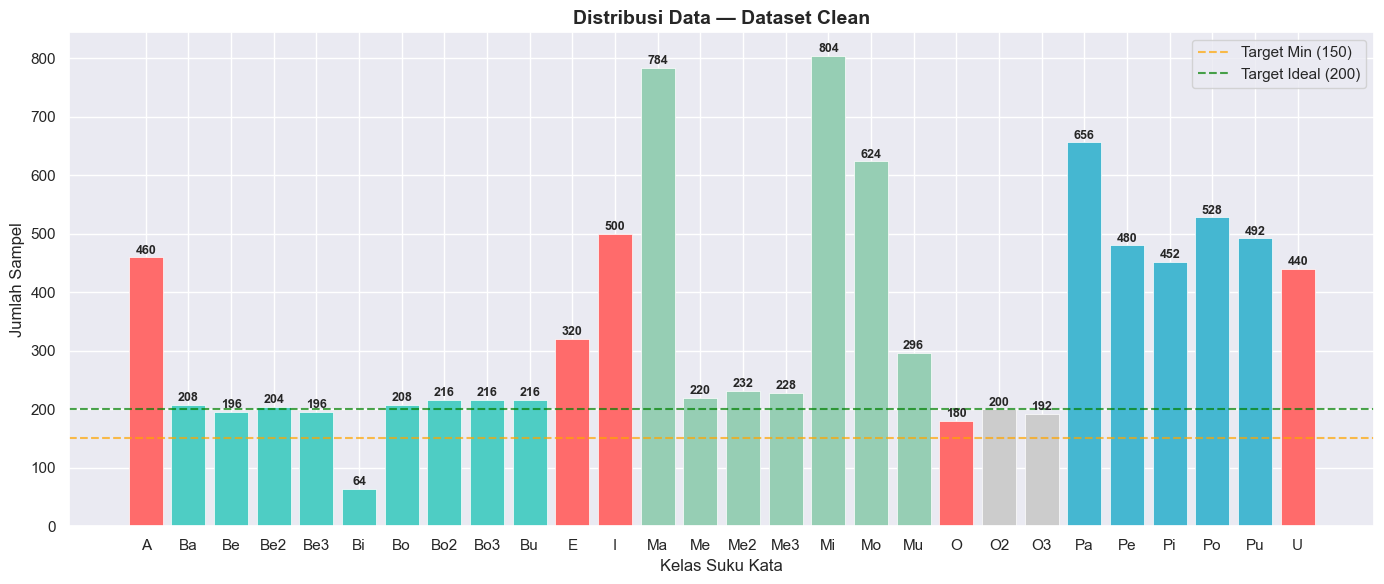


2️⃣  Distribusi Durasi Audio


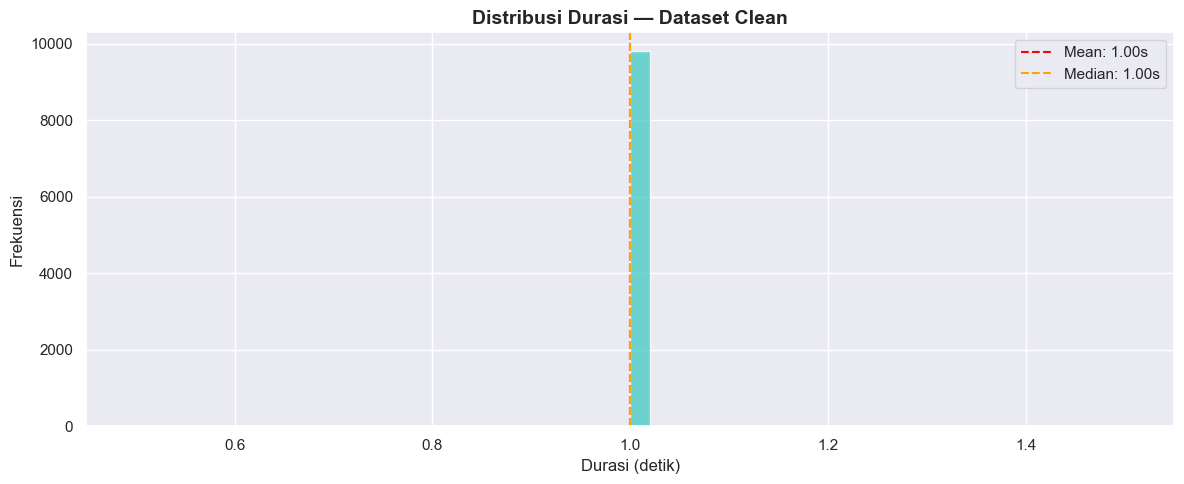


3️⃣  Distribusi RMS Energy Per Kelas


d:\STUPEN\Heartz\data-science\eda.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y="rms", palette="husl", ax=ax)


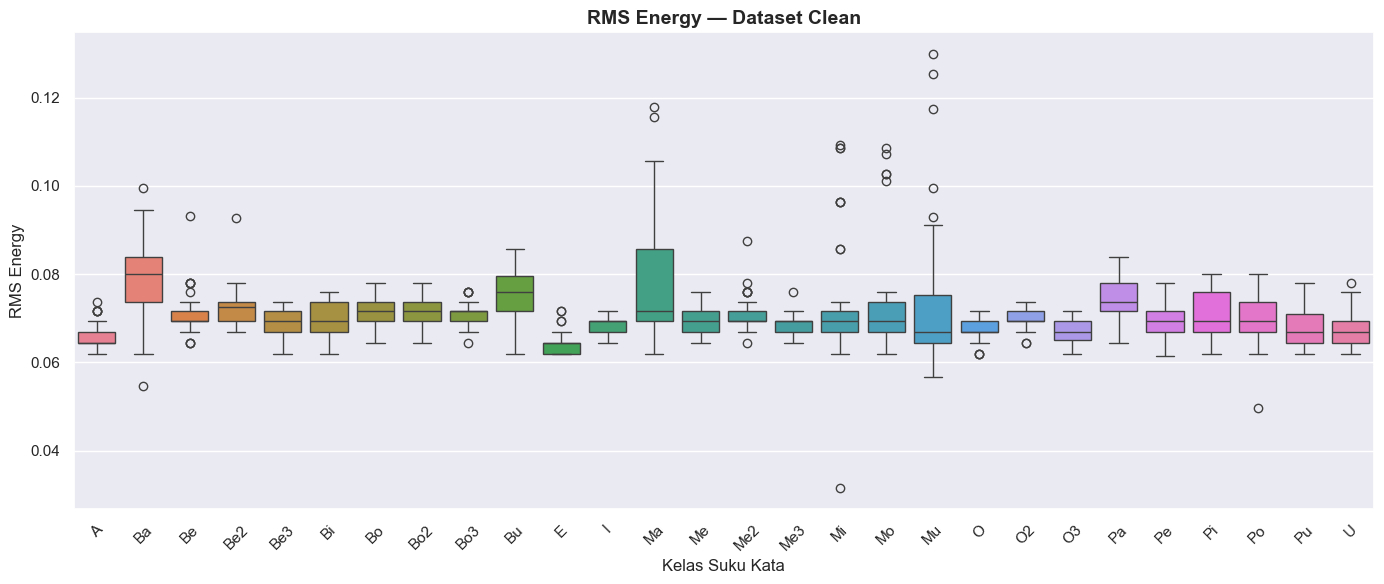


4️⃣  Contoh Waveform & Mel-Spectrogram

   📌 Vokal (contoh: A)


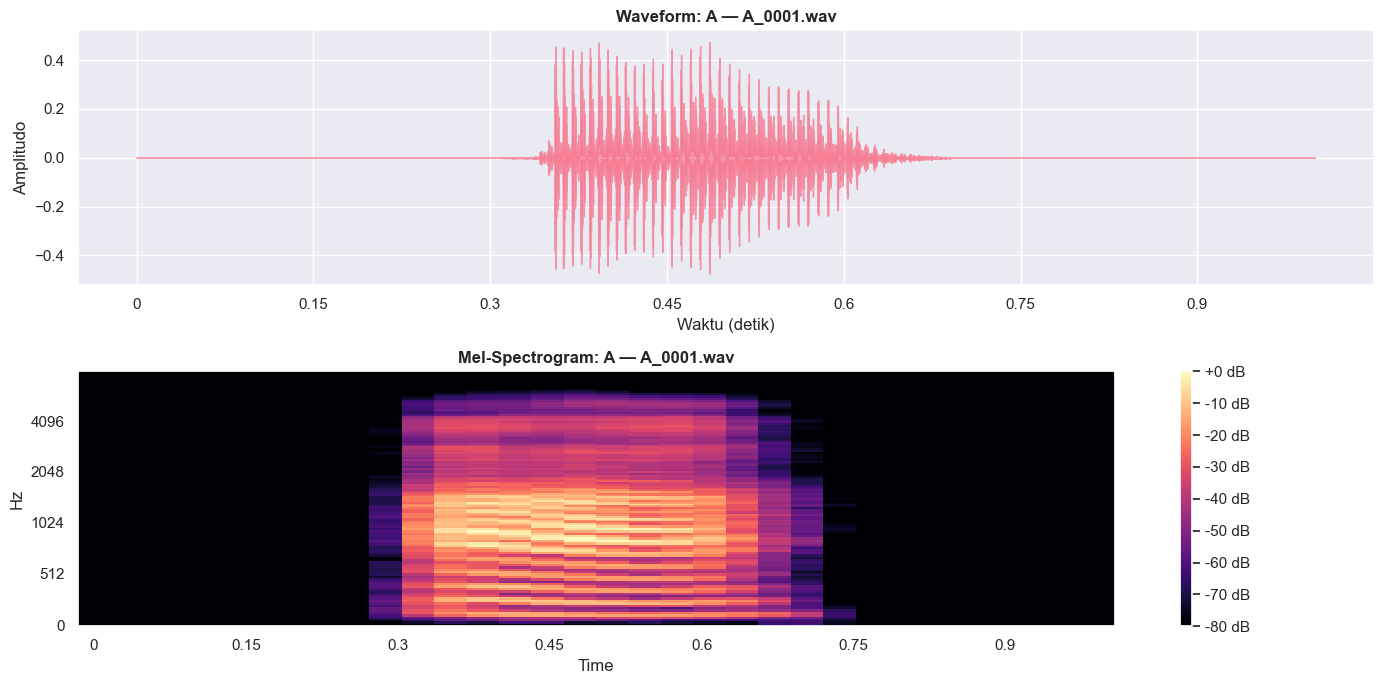


   📌 Ba-set (contoh: Ba)


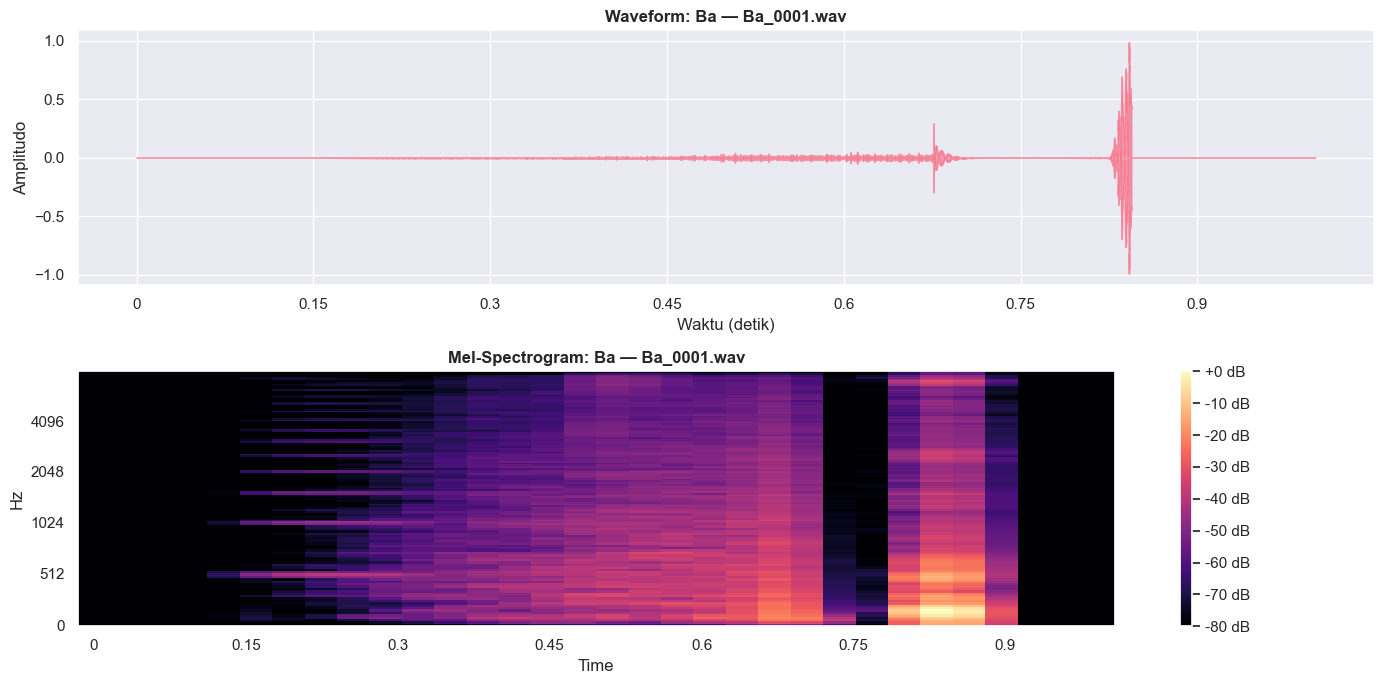


   📌 Pa-set (contoh: Pa)


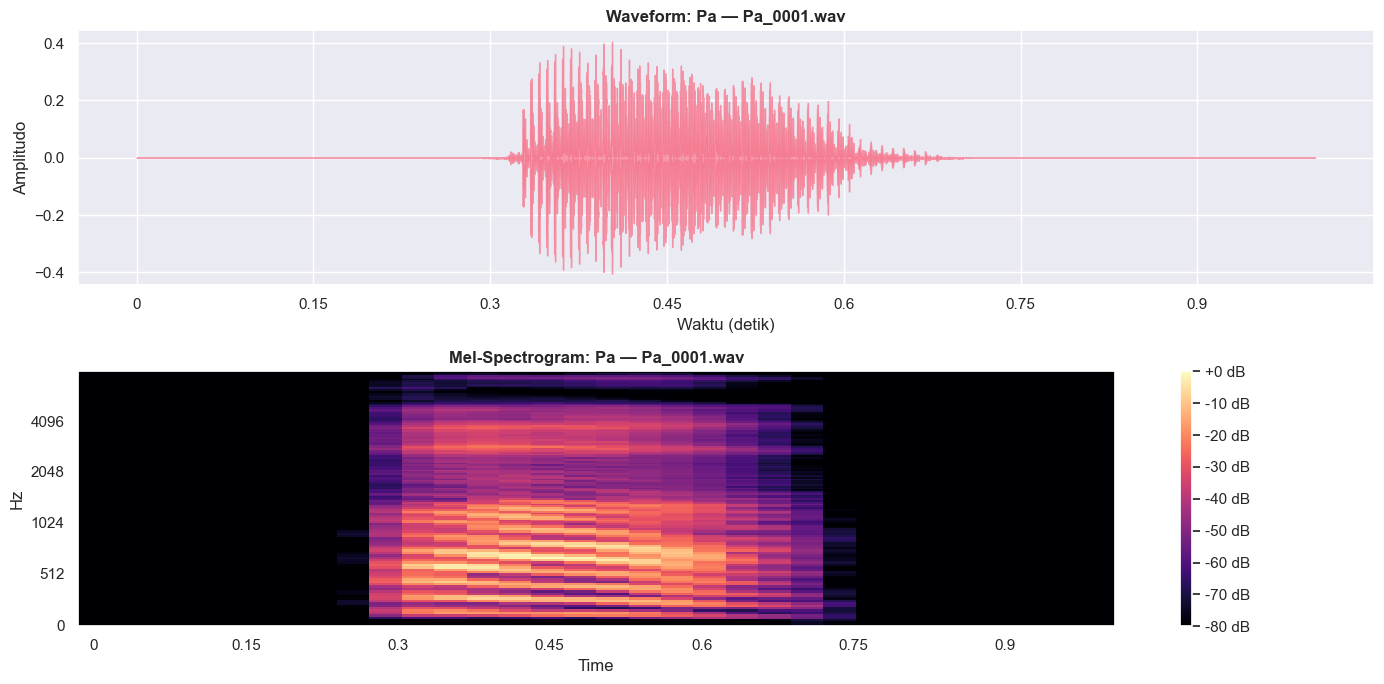


   📌 Ma-set (contoh: Ma)


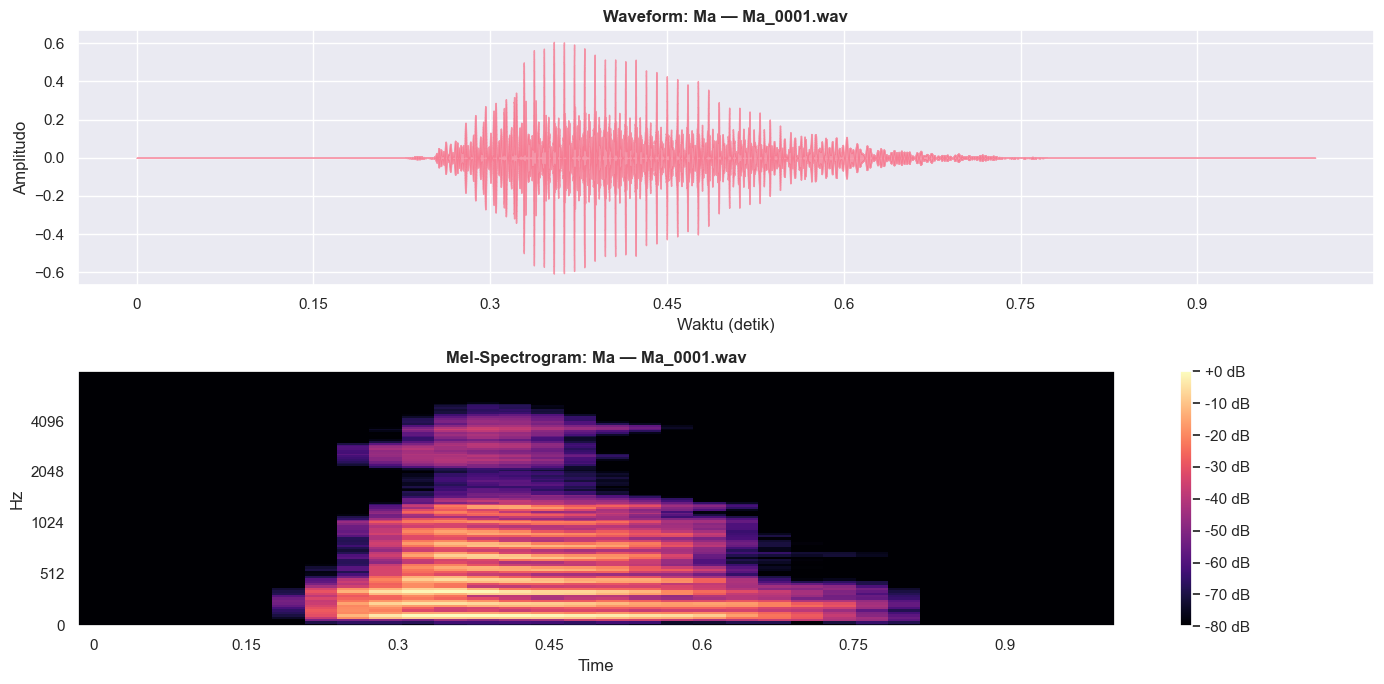


✅ EDA Report selesai!


In [18]:
# EDA Report lengkap untuk dataset CLEAN
full_eda_report(CLEAN_DIR, "Dataset Clean")


📊 EDA Report: Dataset Augmented
   Path: D:\STUPEN\Heartz\data-science\dataset\augmented

1️⃣  Distribusi Jumlah Data Per Kelas


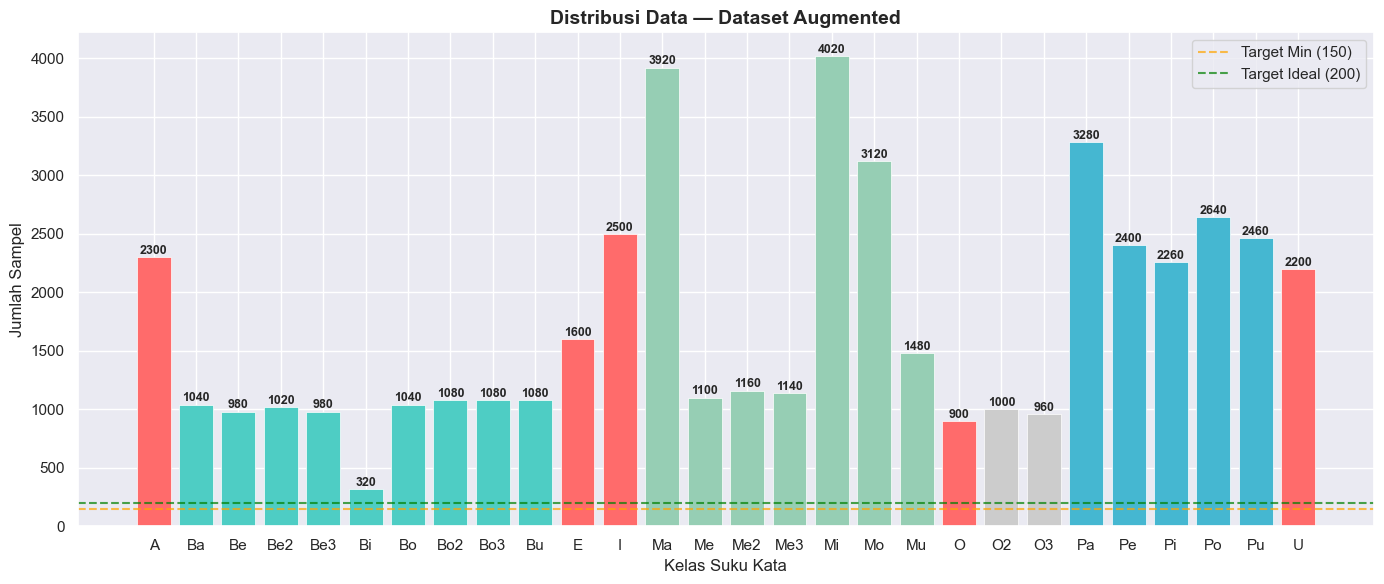


2️⃣  Distribusi Durasi Audio


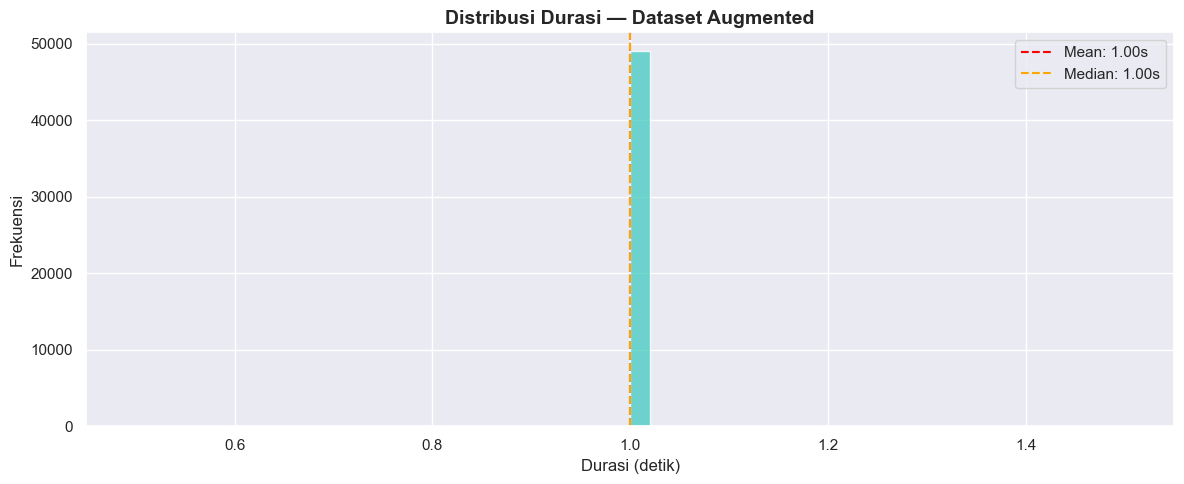


3️⃣  Distribusi RMS Energy Per Kelas


d:\STUPEN\Heartz\data-science\eda.py:212: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y="rms", palette="husl", ax=ax)


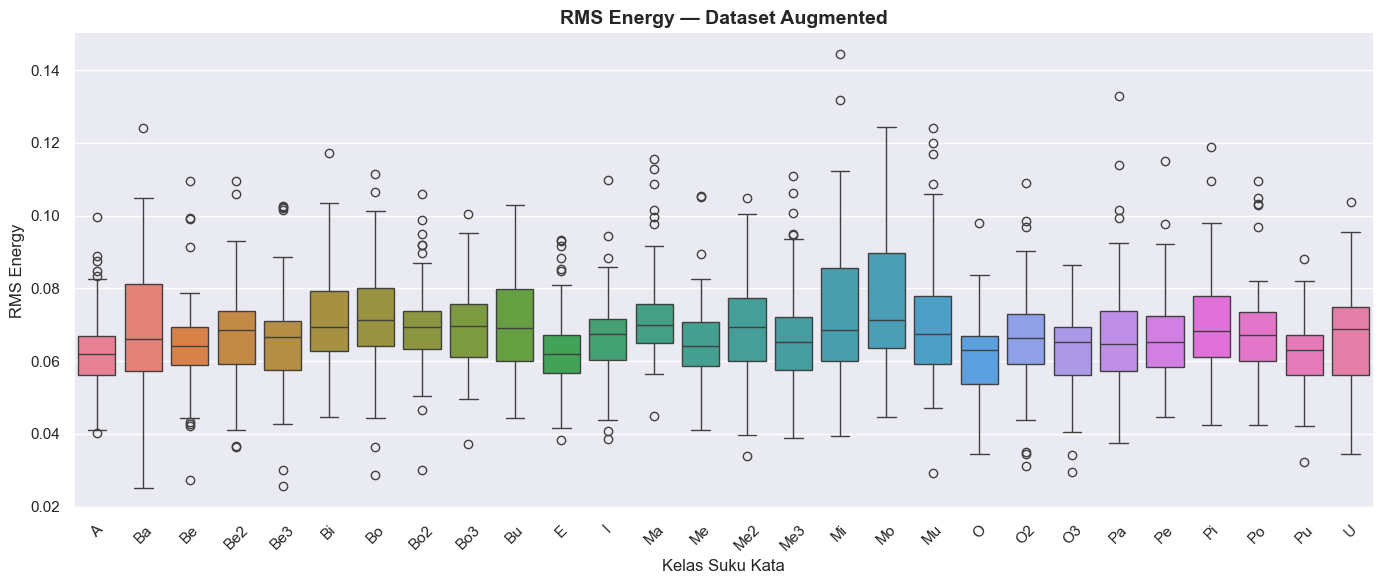


4️⃣  Contoh Waveform & Mel-Spectrogram

   📌 Vokal (contoh: A)


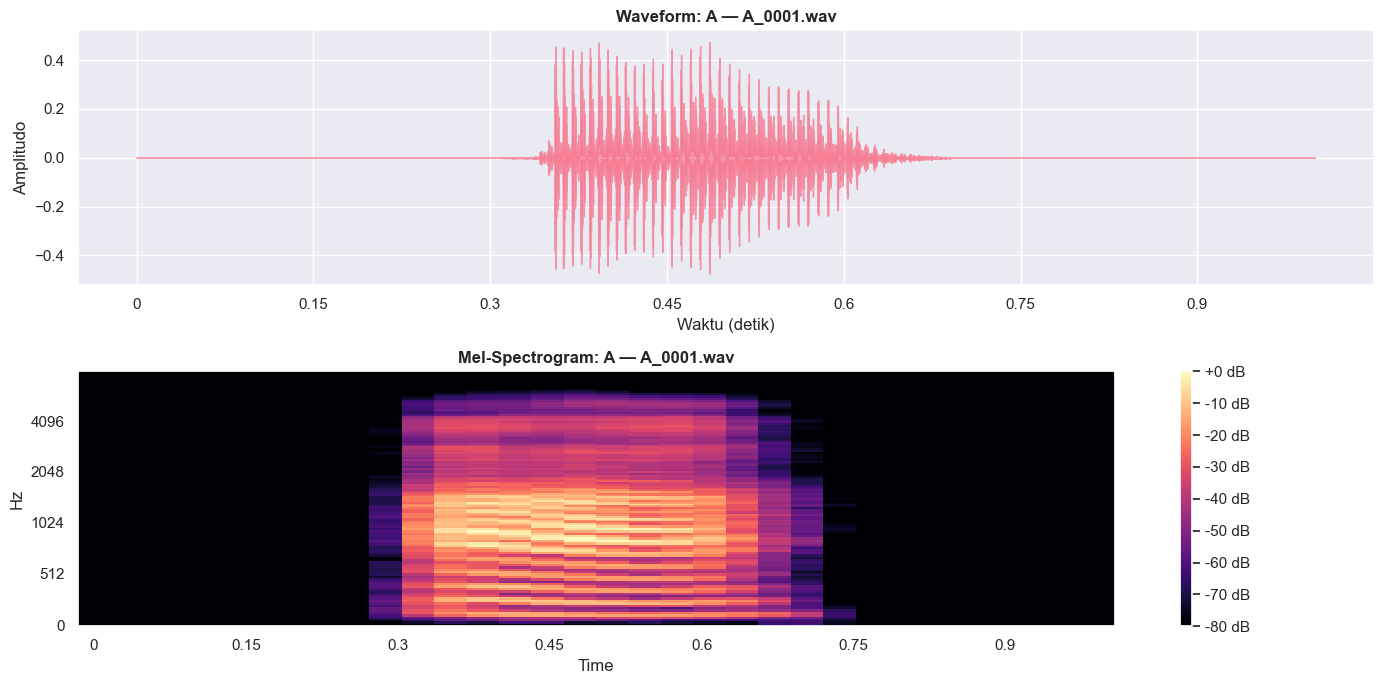


   📌 Ba-set (contoh: Ba)


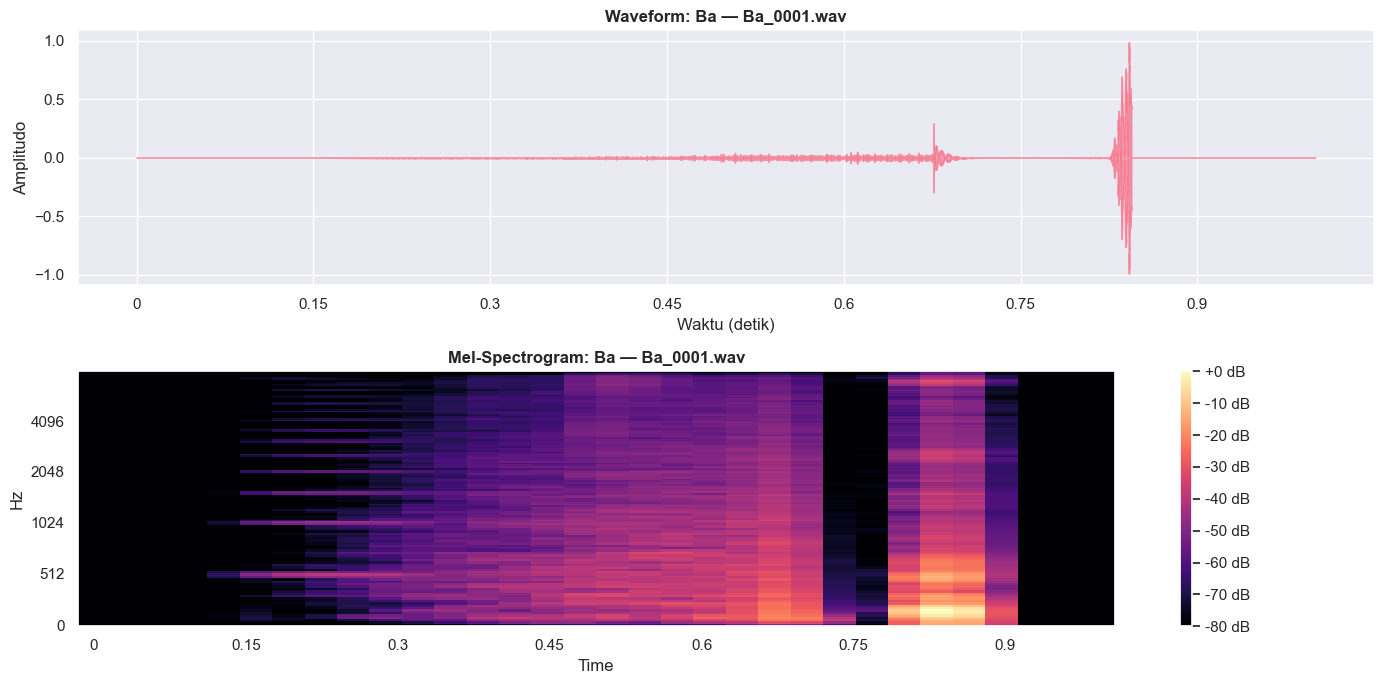


   📌 Pa-set (contoh: Pa)


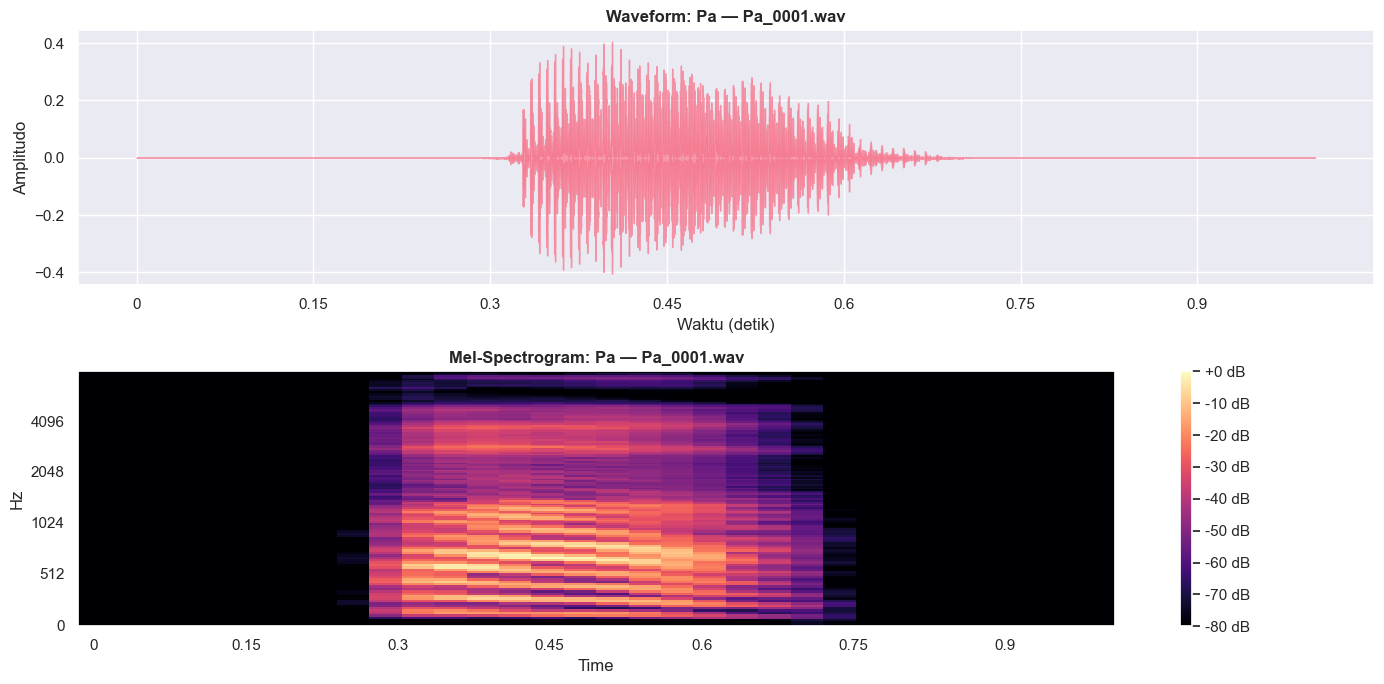


   📌 Ma-set (contoh: Ma)


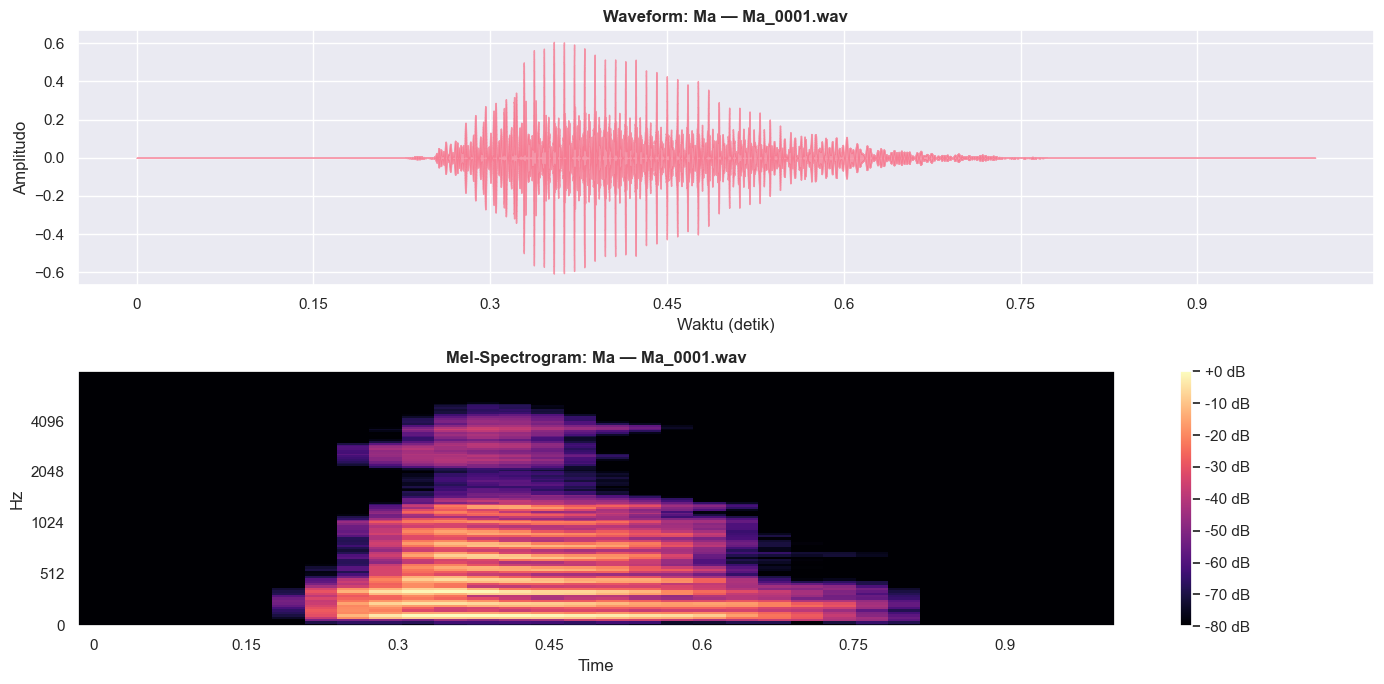


✅ EDA Report selesai!


In [19]:
# EDA untuk dataset AUGMENTED (yang akan dipakai training)
full_eda_report(AUGMENTED_DIR, "Dataset Augmented")

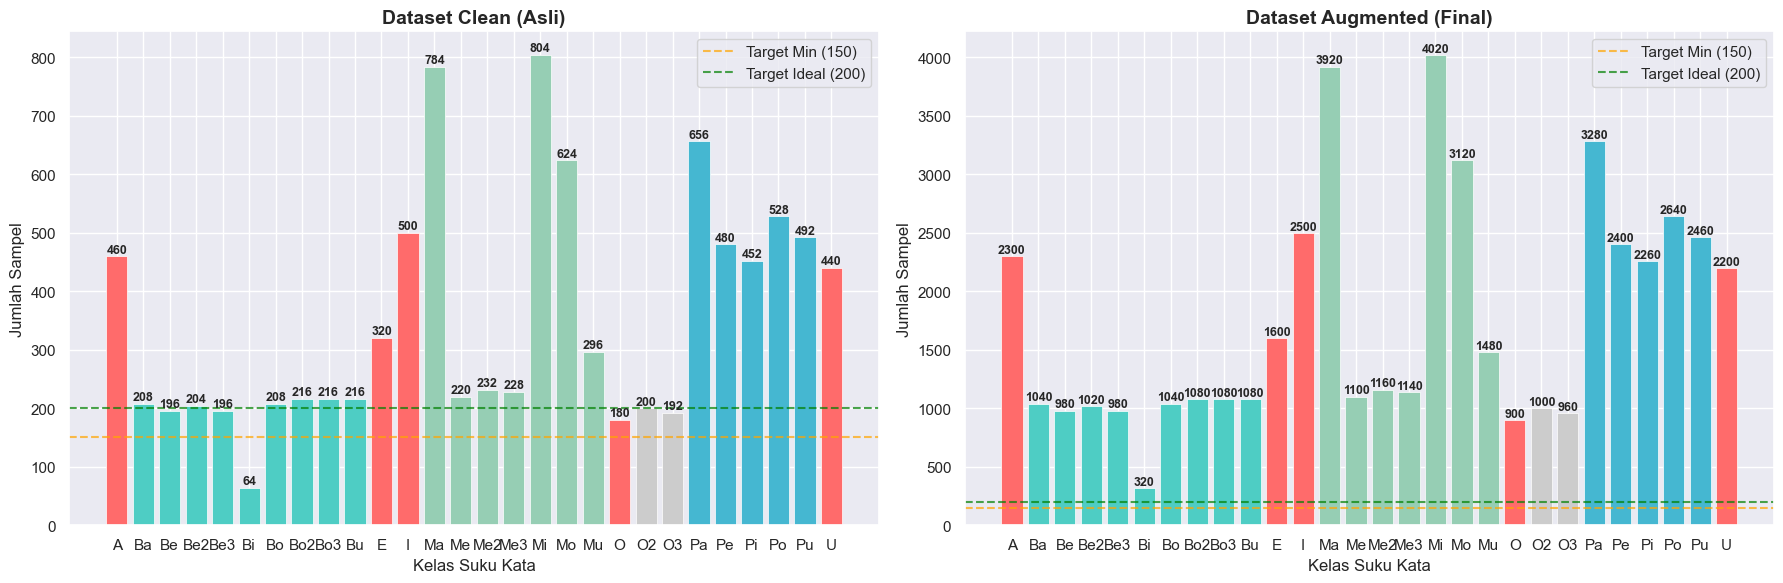

In [20]:
# Perbandingan distribusi: Clean vs Augmented
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_class_distribution(CLEAN_DIR, "Dataset Clean (Asli)", ax=axes[0])
plot_class_distribution(AUGMENTED_DIR, "Dataset Augmented (Final)", ax=axes[1])

plt.tight_layout()
plt.show()

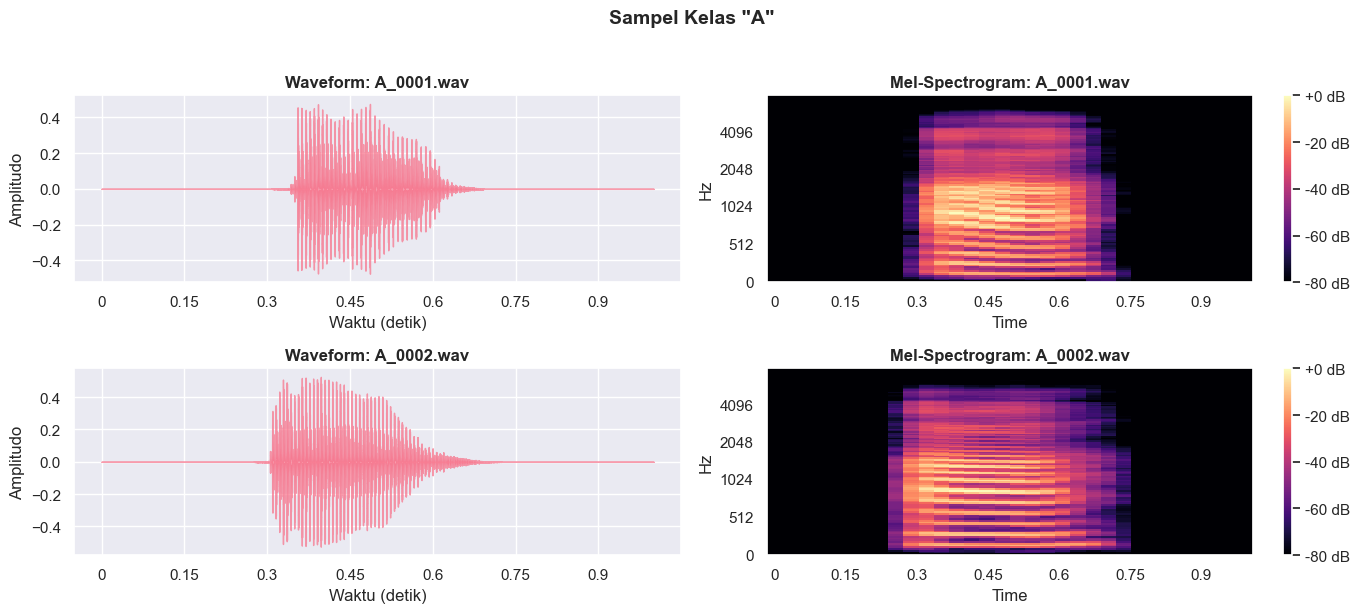

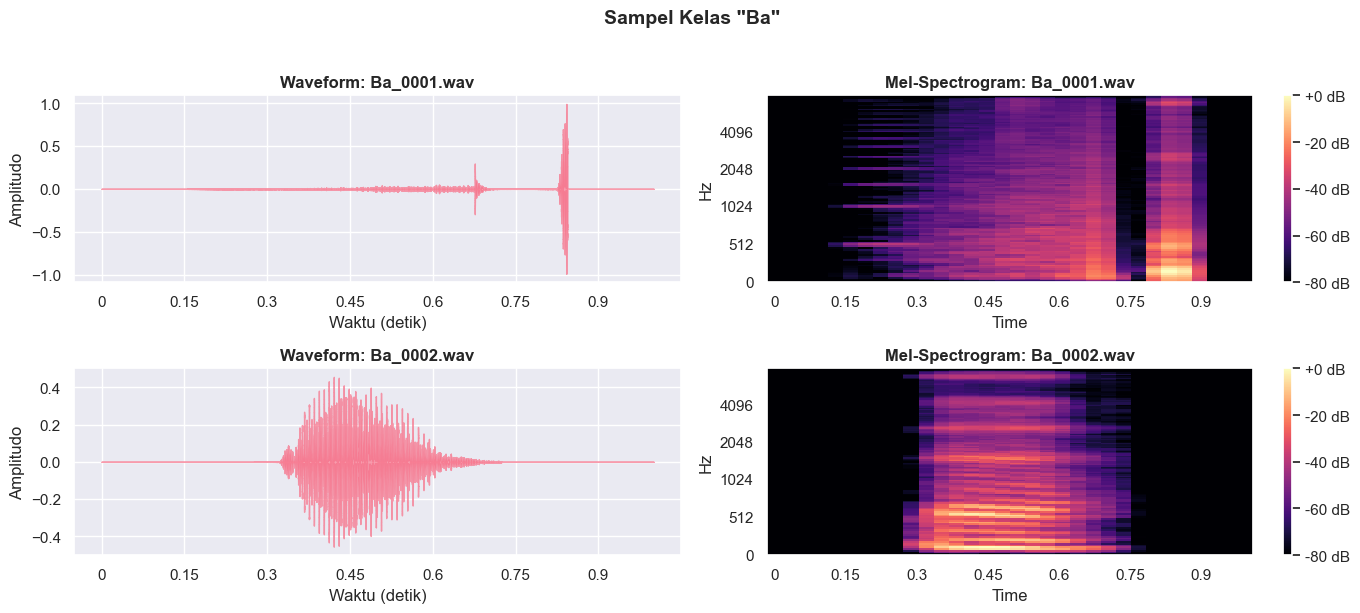

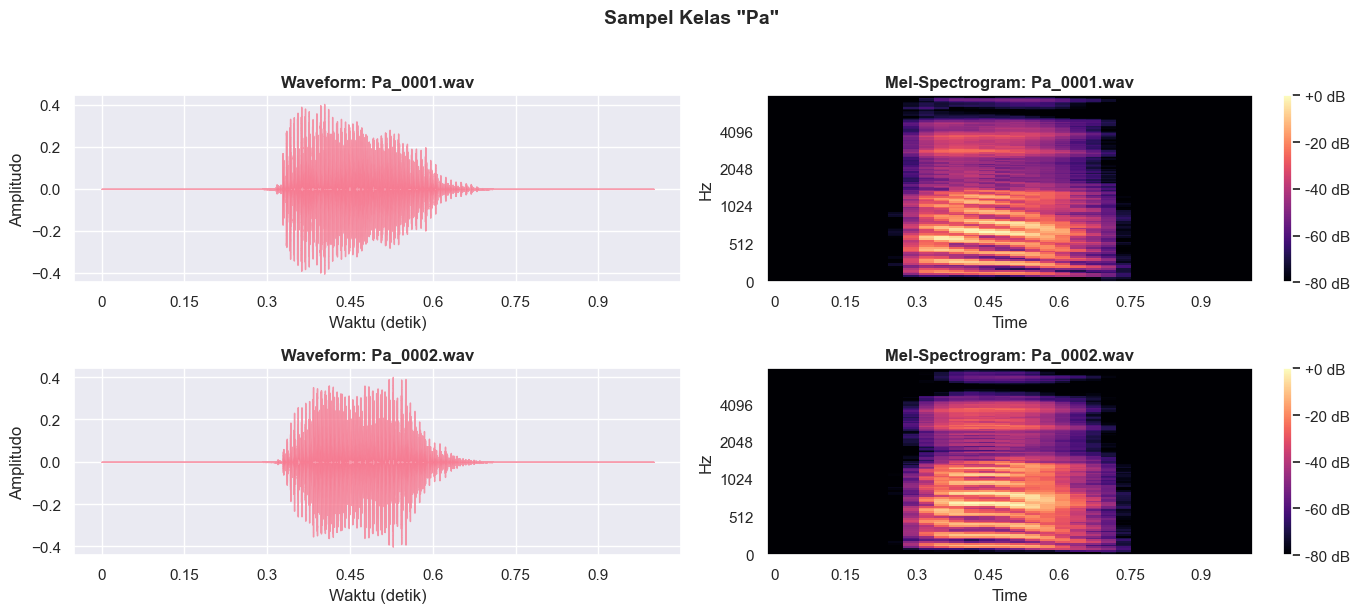

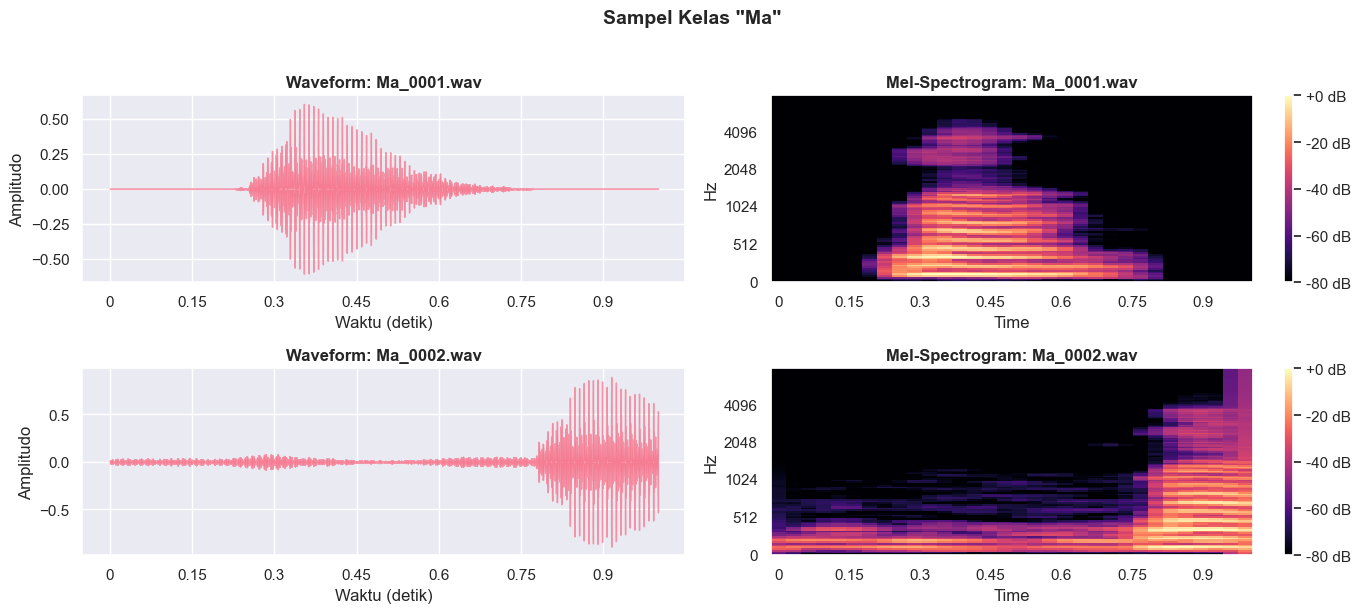

In [21]:
# Lihat contoh sampel dari setiap kelompok kelas
for sample_cls in ["A", "Ba", "Pa", "Ma"]:
    plot_class_samples(CLEAN_DIR, sample_cls, n_samples=2)
    plt.show()

---
## 📦 STEP 6: Export & Serah Terima

Generate metadata CSV dan ringkasan untuk tim AI Engineering.

In [22]:
# Generate metadata CSV untuk dataset clean
create_metadata_csv(CLEAN_DIR, METADATA_DIR / "metadata_clean.csv")

✅ Metadata disimpan: D:\STUPEN\Heartz\data-science\dataset\metadata\metadata_clean.csv (9812 entries)


[{'filename': 'A_0001.wav',
  'label': 'A',
  'duration_sec': 1.0,
  'sample_rate': 16000,
  'rms_energy': 0.061968,
  'peak_amplitude': 0.474518,
  'path': 'D:\\STUPEN\\Heartz\\data-science\\dataset\\clean\\A\\A_0001.wav'},
 {'filename': 'A_0002.wav',
  'label': 'A',
  'duration_sec': 1.0,
  'sample_rate': 16000,
  'rms_energy': 0.066933,
  'peak_amplitude': 0.524933,
  'path': 'D:\\STUPEN\\Heartz\\data-science\\dataset\\clean\\A\\A_0002.wav'},
 {'filename': 'A_0003.wav',
  'label': 'A',
  'duration_sec': 1.0,
  'sample_rate': 16000,
  'rms_energy': 0.066933,
  'peak_amplitude': 0.596039,
  'path': 'D:\\STUPEN\\Heartz\\data-science\\dataset\\clean\\A\\A_0003.wav'},
 {'filename': 'A_0004.wav',
  'label': 'A',
  'duration_sec': 1.0,
  'sample_rate': 16000,
  'rms_energy': 0.064498,
  'peak_amplitude': 0.517822,
  'path': 'D:\\STUPEN\\Heartz\\data-science\\dataset\\clean\\A\\A_0004.wav'},
 {'filename': 'A_0005.wav',
  'label': 'A',
  'duration_sec': 1.0,
  'sample_rate': 16000,
  'rms_en

In [23]:
# Generate metadata CSV untuk dataset augmented
create_metadata_csv(AUGMENTED_DIR, METADATA_DIR / "metadata_augmented.csv")

✅ Metadata disimpan: D:\STUPEN\Heartz\data-science\dataset\metadata\metadata_augmented.csv (49060 entries)


[{'filename': 'A_0001.wav',
  'label': 'A',
  'duration_sec': 1.0,
  'sample_rate': 16000,
  'rms_energy': 0.061968,
  'peak_amplitude': 0.474518,
  'path': 'D:\\STUPEN\\Heartz\\data-science\\dataset\\augmented\\A\\A_0001.wav'},
 {'filename': 'A_0001_aug01.wav',
  'label': 'A',
  'duration_sec': 1.0,
  'sample_rate': 16000,
  'rms_energy': 0.082539,
  'peak_amplitude': 0.640564,
  'path': 'D:\\STUPEN\\Heartz\\data-science\\dataset\\augmented\\A\\A_0001_aug01.wav'},
 {'filename': 'A_0001_aug02.wav',
  'label': 'A',
  'duration_sec': 1.0,
  'sample_rate': 16000,
  'rms_energy': 0.053713,
  'peak_amplitude': 0.499023,
  'path': 'D:\\STUPEN\\Heartz\\data-science\\dataset\\augmented\\A\\A_0001_aug02.wav'},
 {'filename': 'A_0001_aug03.wav',
  'label': 'A',
  'duration_sec': 1.0,
  'sample_rate': 16000,
  'rms_energy': 0.040214,
  'peak_amplitude': 0.398468,
  'path': 'D:\\STUPEN\\Heartz\\data-science\\dataset\\augmented\\A\\A_0001_aug03.wav'},
 {'filename': 'A_0001_aug04.wav',
  'label': 'A'

In [24]:
# Ringkasan final
print("\n" + "="*60)
print("📋 RINGKASAN FINAL DATASET HEARTZ")
print("="*60)

print("\n--- Dataset Clean (Asli) ---")
clean_counts = print_dataset_summary(CLEAN_DIR, "Clean")

print("\n--- Dataset Augmented (Untuk Training) ---")
aug_counts = print_dataset_summary(AUGMENTED_DIR, "Augmented")

if clean_counts and aug_counts:
    total_clean = sum(clean_counts.values())
    total_aug = sum(aug_counts.values())
    print(f"\n📈 Rasio augmentasi: {total_aug/max(total_clean,1):.1f}x")
    print(f"\n✅ Dataset siap diserahkan ke tim AI Engineering!")
    print(f"   - Folder training: dataset/augmented/")
    print(f"   - Metadata: dataset/metadata/")
    print(f"   - Format: .wav, {SAMPLE_RATE}Hz, mono, ~{CLIP_DURATION_TARGET}s per clip")


📋 RINGKASAN FINAL DATASET HEARTZ

--- Dataset Clean (Asli) ---

📊 Clean
Kelas        Jumlah
------------------
A               460  ✅
Ba              208  ✅
Be              196  ✅
Be2             204  ✅
Be3             196  ✅
Bi               64  ❌
Bo              208  ✅
Bo2             216  ✅
Bo3             216  ✅
Bu              216  ✅
E               320  ✅
I               500  ✅
Ma              784  ✅
Me              220  ✅
Me2             232  ✅
Me3             228  ✅
Mi              804  ✅
Mo              624  ✅
Mu              296  ✅
O               180  ✅
O2              200  ✅
O3              192  ✅
Pa              656  ✅
Pe              480  ✅
Pi              452  ✅
Po              528  ✅
Pu              492  ✅
U               440  ✅
------------------
TOTAL          9812
Min              64
Max             804
Rata-rata     350.4

--- Dataset Augmented (Untuk Training) ---

📊 Augmented
Kelas        Jumlah
------------------
A              2300  ✅
Ba             1040  ✅
Be 